In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RAW_DATA_PATH = "../dataset/behavioral/raw/codequest_roundDetails_synthetic.xlsx"

df_raw = pd.read_excel(RAW_DATA_PATH, sheet_name='roundDetails')

print(f"Shape: {df_raw.shape}")
print(f"\nColumn data types:\n{df_raw.dtypes}")
df_raw.head(10)

Shape: (9000, 9)

Column data types:
round_id                                 str
player_id                                str
level_id                               int64
session_timestamp             datetime64[us]
attempts_count                       float64
time_taken_seconds                   float64
misconception_repeat_count           float64
combo_breaks                         float64
true_pattern_DEBUG_ONLY                  str
dtype: object


,round_id,player_id,level_id,session_timestamp,attempts_count,time_taken_seconds,misconception_repeat_count,combo_breaks,true_pattern_DEBUG_ONLY
0,RND07941,PLYR0055,71,2026-08-13 14:18:22,9.0,60.00,3.0,0.0,struggling
1,RND01163,PLYR0011,26,2026-07-29 23:02:41,3.0,14.48,0.0,1.0,typical
2,RND00583,PLYR0020,31,2026-06-08 22:43:57,3.0,57.51,1.0,2.0,typical
3,RND04082,PLYR0107,8,2026-07-29 02:18:00,3.0,42.92,0.0,3.0,typical
4,RND08413,PLYR0057,27,2026-06-15 05:32:04,5.0,89.85,3.0,-1.0,struggling
5,RND08731,PLYR0101,47,2026-06-15 04:25:58,5.0,104.74,1.0,1.0,struggling
6,RND05937,PLYR0137,61,2026-07-24 10:08:47,6.0,30.15,1.0,1.0,typical
7,RND08284,PLYR0138,67,2026-07-14 19:54:24,5.0,73.50,3.0,2.0,struggling
8,RND03707,PLYR0032,47,2026-06-11 13:06:51,1.0,31.07,1.0,1.0,typical
9,RND04072,PLYR0109,69,2026-06-09 09:23:24,7.0,31.31,1.0,1.0,typical


In [2]:
missing_counts = df_raw.isnull().sum()
missing_percent = (missing_counts / len(df_raw)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent.round(2)
})

print("Missing Values Summary:\n")
print(missing_summary[missing_summary['Missing Count'] > 0])


rows_with_any_missing = df_raw.isnull().any(axis=1).sum()
print(f"\nRows with at least one missing value: {rows_with_any_missing} ({rows_with_any_missing/len(df_raw)*100:.2f}%)")

Missing Values Summary:

                            Missing Count  Missing %
attempts_count                        134       1.49
time_taken_seconds                    134       1.49
misconception_repeat_count            135       1.50
combo_breaks                          135       1.50

Rows with at least one missing value: 532 (5.91%)


In [3]:

exact_duplicates = df_raw.duplicated().sum()
print(f"Exact duplicate rows (all columns match): {exact_duplicates}")


duplicate_round_ids = df_raw['round_id'].duplicated().sum()
print(f"Duplicate round_ids: {duplicate_round_ids}")


dup_id_mask = df_raw['round_id'].duplicated(keep=False)
duplicated_rows_sample = df_raw[dup_id_mask].sort_values('round_id').head(6)
duplicated_rows_sample

Exact duplicate rows (all columns match): 173
Duplicate round_ids: 200


,round_id,player_id,level_id,session_timestamp,attempts_count,time_taken_seconds,misconception_repeat_count,combo_breaks,true_pattern_DEBUG_ONLY
367,RND00015,PLYR0110,31,2026-06-17 23:34:44,2.0,57.56,0.0,2.0,typical
6490,RND00015,PLYR0110,31,2026-06-17 23:34:44,2.0,NaN,0.0,2.0,typical
3740,RND00081,PLYR0039,42,2026-07-18 21:43:54,7.0,68.51,1.0,2.0,typical
48,RND00081,PLYR0039,42,2026-07-18 21:43:54,7.0,68.51,1.0,2.0,typical
8813,RND00096,PLYR0023,43,2026-06-08 00:45:02,4.0,99.22,0.0,0.0,typical
144,RND00096,PLYR0023,43,2026-06-08 00:45:02,4.0,99.22,0.0,0.0,typical


In [4]:
print("=== Invalid Value Checks ===\n")


neg_attempts = (df_raw['attempts_count'] < 0).sum()
print(f"Negative attempts_count: {neg_attempts}")


neg_time = (df_raw['time_taken_seconds'] < 0).sum()
print(f"Negative time_taken_seconds: {neg_time}")


extreme_time = (df_raw['time_taken_seconds'] > 1000).sum()
print(f"Extreme time_taken_seconds (>1000s): {extreme_time}")

neg_combo = (df_raw['combo_breaks'] < 0).sum()
print(f"Negative combo_breaks: {neg_combo}")


neg_misconception = (df_raw['misconception_repeat_count'] < 0).sum()
print(f"Negative misconception_repeat_count: {neg_misconception}")

total_invalid_rows = (
    (df_raw['attempts_count'] < 0) |
    (df_raw['time_taken_seconds'] < 0) |
    (df_raw['time_taken_seconds'] > 1000) |
    (df_raw['combo_breaks'] < 0) |
    (df_raw['misconception_repeat_count'] < 0)
).sum()
print(f"\nTotal rows with at least one invalid value: {total_invalid_rows}")


invalid_mask = (
    (df_raw['attempts_count'] < 0) |
    (df_raw['time_taken_seconds'] < 0) |
    (df_raw['time_taken_seconds'] > 1000) |
    (df_raw['combo_breaks'] < 0)
)
df_raw[invalid_mask].head(8)

=== Invalid Value Checks ===

Negative attempts_count: 24
Negative time_taken_seconds: 22
Extreme time_taken_seconds (>1000s): 25
Negative combo_breaks: 19
Negative misconception_repeat_count: 0

Total rows with at least one invalid value: 90


,round_id,player_id,level_id,session_timestamp,attempts_count,time_taken_seconds,misconception_repeat_count,combo_breaks,true_pattern_DEBUG_ONLY
4,RND08413,PLYR0057,27,2026-06-15 05:32:04,5.0,89.85,3.0,-1.0,struggling
150,RND01618,PLYR0059,87,2026-06-25 04:32:16,-1.0,72.80,1.0,1.0,typical
385,RND01740,PLYR0003,71,2026-06-24 08:43:52,4.0,-18.15,1.0,1.0,typical
554,RND07124,PLYR0042,44,2026-06-26 06:00:33,6.0,8759.06,1.0,3.0,typical
580,RND08206,PLYR0053,26,2026-06-13 00:07:46,4.0,60.00,0.0,-1.0,struggling
600,RND05506,PLYR0036,64,2026-07-14 23:38:18,10.0,-18.04,1.0,7.0,typical
753,RND05655,PLYR0096,73,2026-07-10 16:27:03,-2.0,50.86,1.0,3.0,typical
1044,RND01264,PLYR0057,26,2026-06-24 00:12:17,5.0,9795.09,2.0,0.0,typical


Class distribution (for validation reference only):

true_pattern_DEBUG_ONLY
typical       7652
struggling    1348
Name: count, dtype: int64


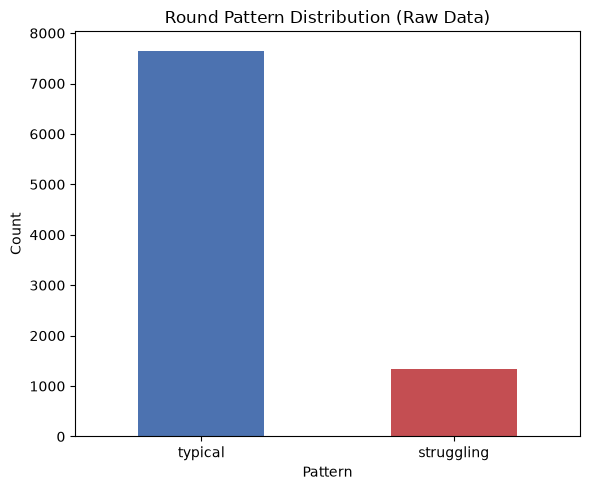

In [5]:
class_counts = df_raw['true_pattern_DEBUG_ONLY'].value_counts()
print("Class distribution (for validation reference only):\n")
print(class_counts)

plt.figure(figsize=(6, 5))
class_counts.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Round Pattern Distribution (Raw Data)')
plt.xlabel('Pattern')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/08_behavioral_class_distribution.png', dpi=150)
plt.show()

In [6]:
print(f"Original dataset size: {len(df_raw)}")


df_clean = df_raw.drop_duplicates(subset='round_id', keep='first').copy()
print(f"After removing duplicate round_ids: {len(df_clean)} (removed {len(df_raw) - len(df_clean)})")


before_missing_removal = len(df_clean)
df_clean = df_clean.dropna(subset=['attempts_count', 'time_taken_seconds',
                                    'misconception_repeat_count', 'combo_breaks'])
print(f"After removing rows with missing values: {len(df_clean)} (removed {before_missing_removal - len(df_clean)})")


before_invalid_removal = len(df_clean)
valid_mask = (
    (df_clean['attempts_count'] >= 0) &
    (df_clean['time_taken_seconds'] >= 0) &
    (df_clean['time_taken_seconds'] <= 1000) &
    (df_clean['combo_breaks'] >= 0) &
    (df_clean['misconception_repeat_count'] >= 0)
)
df_clean = df_clean[valid_mask]
print(f"After removing invalid-value rows: {len(df_clean)} (removed {before_invalid_removal - len(df_clean)})")

print(f"\nFinal clean dataset size: {len(df_clean)}")
print(f"Total rows removed: {len(df_raw) - len(df_clean)} ({(len(df_raw)-len(df_clean))/len(df_raw)*100:.2f}%)")

df_clean.head(8)

Original dataset size: 9000
After removing duplicate round_ids: 8800 (removed 200)
After removing rows with missing values: 8280 (removed 520)
After removing invalid-value rows: 8196 (removed 84)

Final clean dataset size: 8196
Total rows removed: 804 (8.93%)


,round_id,player_id,level_id,session_timestamp,attempts_count,time_taken_seconds,misconception_repeat_count,combo_breaks,true_pattern_DEBUG_ONLY
0,RND07941,PLYR0055,71,2026-08-13 14:18:22,9.0,60.00,3.0,0.0,struggling
1,RND01163,PLYR0011,26,2026-07-29 23:02:41,3.0,14.48,0.0,1.0,typical
2,RND00583,PLYR0020,31,2026-06-08 22:43:57,3.0,57.51,1.0,2.0,typical
3,RND04082,PLYR0107,8,2026-07-29 02:18:00,3.0,42.92,0.0,3.0,typical
5,RND08731,PLYR0101,47,2026-06-15 04:25:58,5.0,104.74,1.0,1.0,struggling
6,RND05937,PLYR0137,61,2026-07-24 10:08:47,6.0,30.15,1.0,1.0,typical
7,RND08284,PLYR0138,67,2026-07-14 19:54:24,5.0,73.50,3.0,2.0,struggling
8,RND03707,PLYR0032,47,2026-06-11 13:06:51,1.0,31.07,1.0,1.0,typical


In [7]:
print("Class distribution BEFORE cleaning:")
print(df_raw['true_pattern_DEBUG_ONLY'].value_counts())
print(f"Struggling %: {(df_raw['true_pattern_DEBUG_ONLY']=='struggling').mean()*100:.2f}%")

print("\nClass distribution AFTER cleaning:")
print(df_clean['true_pattern_DEBUG_ONLY'].value_counts())
print(f"Struggling %: {(df_clean['true_pattern_DEBUG_ONLY']=='struggling').mean()*100:.2f}%")

Class distribution BEFORE cleaning:
true_pattern_DEBUG_ONLY
typical       7652
struggling    1348
Name: count, dtype: int64
Struggling %: 14.98%

Class distribution AFTER cleaning:
true_pattern_DEBUG_ONLY
typical       6970
struggling    1226
Name: count, dtype: int64
Struggling %: 14.96%


In [8]:
CLEAN_DATA_PATH = "../dataset/behavioral/clean/roundDetails_clean.csv"

df_clean.to_csv(CLEAN_DATA_PATH, index=False)

print(f"Clean dataset saved: {CLEAN_DATA_PATH}")
print(f"Final shape: {df_clean.shape}")

Clean dataset saved: ../dataset/behavioral/clean/roundDetails_clean.csv
Final shape: (8196, 9)


In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

df_clean = pd.read_csv("../dataset/behavioral/clean/roundDetails_clean.csv")

FEATURE_COLS = ['attempts_count', 'time_taken_seconds',
                'misconception_repeat_count', 'combo_breaks']

X = df_clean[FEATURE_COLS].copy()
y_true = df_clean['true_pattern_DEBUG_ONLY'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"\nFeature statistics:\n{X.describe()}")

Feature matrix shape: (8196, 4)

Feature statistics:
       attempts_count  time_taken_seconds  misconception_repeat_count  \
count     8196.000000         8196.000000                 8196.000000   
mean         4.812225           56.646967                    1.249390   
std          2.017254           24.456175                    1.116095   
min          1.000000            8.000000                    0.000000   
25%          3.000000           39.770000                    0.000000   
50%          5.000000           56.965000                    1.000000   
75%          6.000000           71.542500                    2.000000   
max         14.000000          165.550000                    8.000000   

       combo_breaks  
count   8196.000000  
mean       1.229014  
std        1.108134  
min        0.000000  
25%        0.000000  
50%        1.000000  
75%        2.000000  
max        8.000000  


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling (first row):", X.iloc[0].values)
print("After scaling (first row): ", X_scaled[0])


iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.15,
    random_state=42
)

iso_forest.fit(X_scaled)
iso_preds_raw = iso_forest.predict(X_scaled)


iso_preds = np.where(iso_preds_raw == -1, 'struggling', 'typical')

print("\n=== Isolation Forest Results ===")
print(classification_report(y_true, iso_preds, target_names=['struggling', 'typical']))

Before scaling (first row): [ 9. 60.  3.  0.]
After scaling (first row):  [ 2.07610479  0.13711211  1.56860939 -1.10915207]

=== Isolation Forest Results ===
              precision    recall  f1-score   support

  struggling       0.30      0.30      0.30      1226
     typical       0.88      0.88      0.88      6970

    accuracy                           0.79      8196
   macro avg       0.59      0.59      0.59      8196
weighted avg       0.79      0.79      0.79      8196



In [11]:

oc_svm = OneClassSVM(
    kernel='sigmoid',
    nu=0.15,
    gamma='auto'
)

oc_svm.fit(X_scaled)
svm_preds_raw = oc_svm.predict(X_scaled)


svm_preds = np.where(svm_preds_raw == -1, 'struggling', 'typical')

print("=== One-Class SVM Results ===")
print(classification_report(y_true, svm_preds, target_names=['struggling', 'typical']))

=== One-Class SVM Results ===
              precision    recall  f1-score   support

  struggling       0.21      0.21      0.21      1226
     typical       0.86      0.86      0.86      6970

    accuracy                           0.76      8196
   macro avg       0.54      0.54      0.54      8196
weighted avg       0.76      0.76      0.76      8196



In [12]:

lof = LocalOutlierFactor(
    n_neighbors=12,  
    contamination=0.15
)


lof_preds_raw = lof.fit_predict(X_scaled)


lof_preds = np.where(lof_preds_raw == -1, 'struggling', 'typical')

print("=== Local Outlier Factor Results ===")
print(classification_report(y_true, lof_preds, target_names=['struggling', 'typical']))

=== Local Outlier Factor Results ===
              precision    recall  f1-score   support

  struggling       0.19      0.19      0.19      1226
     typical       0.86      0.86      0.86      6970

    accuracy                           0.76      8196
   macro avg       0.53      0.53      0.53      8196
weighted avg       0.76      0.76      0.76      8196



                  Model  Struggling_F1  Typical_F1  Overall_Accuracy
0      Isolation Forest          0.297       0.876             0.789
1         One-Class SVM          0.210       0.861             0.763
2  Local Outlier Factor          0.194       0.858             0.758


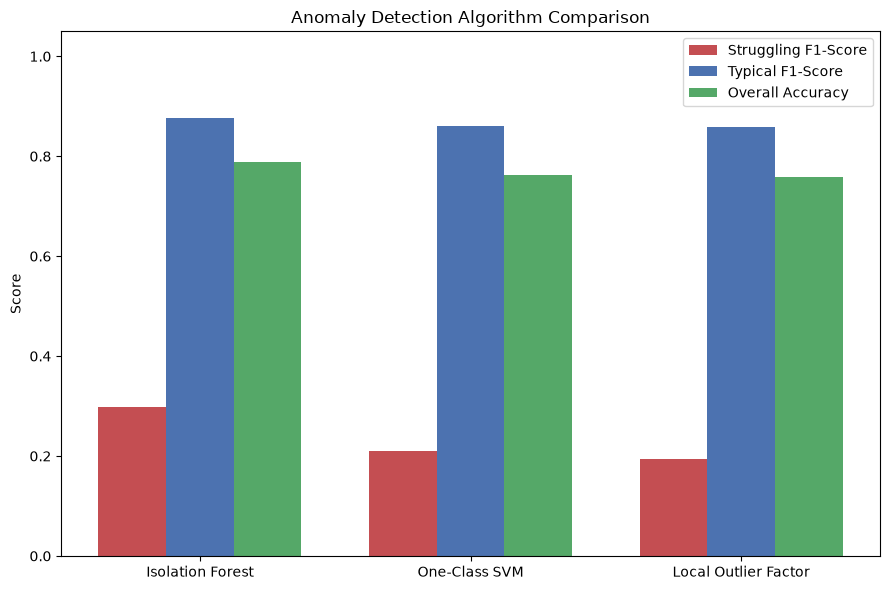


Best performing model: Isolation Forest (selected for final pipeline)


In [13]:
from sklearn.metrics import classification_report

# ---- Cell 10, 11, 12 එකේම prediction results ම reuse කරලා, actual metrics ම extract කරනවා ----
iso_report = classification_report(y_true, iso_preds, target_names=['struggling', 'typical'], output_dict=True)
svm_report = classification_report(y_true, svm_preds, target_names=['struggling', 'typical'], output_dict=True)
lof_report = classification_report(y_true, lof_preds, target_names=['struggling', 'typical'], output_dict=True)

results_summary = pd.DataFrame({
    'Model': ['Isolation Forest', 'One-Class SVM', 'Local Outlier Factor'],
    'Struggling_F1': [iso_report['struggling']['f1-score'], svm_report['struggling']['f1-score'], lof_report['struggling']['f1-score']],
    'Typical_F1': [iso_report['typical']['f1-score'], svm_report['typical']['f1-score'], lof_report['typical']['f1-score']],
    'Overall_Accuracy': [iso_report['accuracy'], svm_report['accuracy'], lof_report['accuracy']]
})

print(results_summary.round(3))

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(results_summary))
width = 0.25

ax.bar(x - width, results_summary['Struggling_F1'], width, label='Struggling F1-Score', color='#C44E52')
ax.bar(x, results_summary['Typical_F1'], width, label='Typical F1-Score', color='#4C72B0')
ax.bar(x + width, results_summary['Overall_Accuracy'], width, label='Overall Accuracy', color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(results_summary['Model'])
ax.set_ylabel('Score')
ax.set_title('Anomaly Detection Algorithm Comparison')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('../outputs/figures/09_algorithm_comparison.png', dpi=150)
plt.show()

best_idx = results_summary['Overall_Accuracy'].idxmax()
print(f"\nBest performing model: {results_summary.loc[best_idx, 'Model']} (selected for final pipeline)")

In [14]:
import joblib

joblib.dump(iso_forest, '../models/isolation_forest_model.joblib')
joblib.dump(scaler, '../models/behavioral_scaler.joblib')

print("Isolation Forest model and scaler saved successfully.")

Isolation Forest model and scaler saved successfully.


In [15]:
import joblib
import numpy as np

model = joblib.load("../models/isolation_forest_model.joblib")
scaler = joblib.load("../models/behavioral_scaler.joblib")

test_cases = [
    {"attempts_count": 3, "time_taken_seconds": 90, "misconception_repeat_count": 3, "combo_breaks": 0},
    {"attempts_count": 3, "time_taken_seconds": 60, "misconception_repeat_count": 1, "combo_breaks": 1},
    {"attempts_count": 3, "time_taken_seconds": 30, "misconception_repeat_count": 0, "combo_breaks": 0},
]

for case in test_cases:
    features = np.array([[case["attempts_count"], case["time_taken_seconds"], 
                           case["misconception_repeat_count"], case["combo_breaks"]]])
    scaled = scaler.transform(features)
    score = model.decision_function(scaled)[0]
    prediction = model.predict(scaled)[0]
    print(f"{case} -> score={score:.4f}, prediction={'struggling' if prediction==-1 else 'typical'}")

{'attempts_count': 3, 'time_taken_seconds': 90, 'misconception_repeat_count': 3, 'combo_breaks': 0} -> score=0.0001, prediction=typical
{'attempts_count': 3, 'time_taken_seconds': 60, 'misconception_repeat_count': 1, 'combo_breaks': 1} -> score=0.1312, prediction=typical
{'attempts_count': 3, 'time_taken_seconds': 30, 'misconception_repeat_count': 0, 'combo_breaks': 0} -> score=0.0561, prediction=typical


c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [16]:
original_offset = model.offset_
print("Original offset_:", original_offset)

for delta in [0, 0.0001, 0.0005, 0.001, 0.005, 0.01]:
    model.offset_ = original_offset + delta
    print(f"\n--- offset shifted by +{delta} ---")
    for case in test_cases:
        features = np.array([[case["attempts_count"], case["time_taken_seconds"], 
                               case["misconception_repeat_count"], case["combo_breaks"]]])
        scaled = scaler.transform(features)
        score = model.decision_function(scaled)[0]
        prediction = model.predict(scaled)[0]
        print(f"{case} -> score={score:.4f}, prediction={'struggling' if prediction==-1 else 'typical'}")

model.offset_ = original_offset  # restore, memory ekema witharai wenас wenwa, file eka save karanna one

Original offset_: -0.5391646647662507

--- offset shifted by +0 ---
{'attempts_count': 3, 'time_taken_seconds': 90, 'misconception_repeat_count': 3, 'combo_breaks': 0} -> score=0.0001, prediction=typical
{'attempts_count': 3, 'time_taken_seconds': 60, 'misconception_repeat_count': 1, 'combo_breaks': 1} -> score=0.1312, prediction=typical
{'attempts_count': 3, 'time_taken_seconds': 30, 'misconception_repeat_count': 0, 'combo_breaks': 0} -> score=0.0561, prediction=typical

--- offset shifted by +0.0001 ---
{'attempts_count': 3, 'time_taken_seconds': 90, 'misconception_repeat_count': 3, 'combo_breaks': 0} -> score=0.0000, prediction=typical
{'attempts_count': 3, 'time_taken_seconds': 60, 'misconception_repeat_count': 1, 'combo_breaks': 1} -> score=0.1311, prediction=typical
{'attempts_count': 3, 'time_taken_seconds': 30, 'misconception_repeat_count': 0, 'combo_breaks': 0} -> score=0.0560, prediction=typical

--- offset shifted by +0.0005 ---
{'attempts_count': 3, 'time_taken_seconds': 90

c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: U

{'attempts_count': 3, 'time_taken_seconds': 60, 'misconception_repeat_count': 1, 'combo_breaks': 1} -> score=0.1302, prediction=typical
{'attempts_count': 3, 'time_taken_seconds': 30, 'misconception_repeat_count': 0, 'combo_breaks': 0} -> score=0.0551, prediction=typical

--- offset shifted by +0.005 ---
{'attempts_count': 3, 'time_taken_seconds': 90, 'misconception_repeat_count': 3, 'combo_breaks': 0} -> score=-0.0049, prediction=struggling
{'attempts_count': 3, 'time_taken_seconds': 60, 'misconception_repeat_count': 1, 'combo_breaks': 1} -> score=0.1262, prediction=typical
{'attempts_count': 3, 'time_taken_seconds': 30, 'misconception_repeat_count': 0, 'combo_breaks': 0} -> score=0.0511, prediction=typical

--- offset shifted by +0.01 ---
{'attempts_count': 3, 'time_taken_seconds': 90, 'misconception_repeat_count': 3, 'combo_breaks': 0} -> score=-0.0099, prediction=struggling
{'attempts_count': 3, 'time_taken_seconds': 60, 'misconception_repeat_count': 1, 'combo_breaks': 1} -> score=

In [17]:
for delta in [0.005, 0.01, 0.02, 0.05, 0.1, 0.2]:
    model.offset_ = original_offset + delta
    print(f"\n--- offset shifted by +{delta} ---")
    for case in test_cases:
        features = np.array([[case["attempts_count"], case["time_taken_seconds"], 
                               case["misconception_repeat_count"], case["combo_breaks"]]])
        scaled = scaler.transform(features)
        score = model.decision_function(scaled)[0]
        prediction = model.predict(scaled)[0]
        print(f"{case} -> score={score:.4f}, prediction={'struggling' if prediction==-1 else 'typical'}")

model.offset_ = original_offset


--- offset shifted by +0.005 ---
{'attempts_count': 3, 'time_taken_seconds': 90, 'misconception_repeat_count': 3, 'combo_breaks': 0} -> score=-0.0049, prediction=struggling
{'attempts_count': 3, 'time_taken_seconds': 60, 'misconception_repeat_count': 1, 'combo_breaks': 1} -> score=0.1262, prediction=typical
{'attempts_count': 3, 'time_taken_seconds': 30, 'misconception_repeat_count': 0, 'combo_breaks': 0} -> score=0.0511, prediction=typical

--- offset shifted by +0.01 ---
{'attempts_count': 3, 'time_taken_seconds': 90, 'misconception_repeat_count': 3, 'combo_breaks': 0} -> score=-0.0099, prediction=struggling
{'attempts_count': 3, 'time_taken_seconds': 60, 'misconception_repeat_count': 1, 'combo_breaks': 1} -> score=0.1212, prediction=typical
{'attempts_count': 3, 'time_taken_seconds': 30, 'misconception_repeat_count': 0, 'combo_breaks': 0} -> score=0.0461, prediction=typical

--- offset shifted by +0.02 ---
{'attempts_count': 3, 'time_taken_seconds': 90, 'misconception_repeat_count'

c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: U

In [18]:
from sklearn.metrics import classification_report
import numpy as np

X_test_scaled = scaler.transform(X_test)
original_offset = model.offset_

for delta in [0, 0.005, 0.01, 0.02, 0.03, 0.05]:
    model.offset_ = original_offset + delta
    preds = model.predict(X_test_scaled)
    preds_labels = np.where(preds == -1, "struggling", "typical")
    print(f"\n=== offset shifted by +{delta} ===")
    print(classification_report(y_test, preds_labels))

model.offset_ = original_offset  # restore

NameError: name 'X_test' is not defined

In [19]:
%whos

Variable                 Type                  Data/Info
--------------------------------------------------------
CLEAN_DATA_PATH          str                   ../dataset/behavioral/cle<...>an/roundDetails_clean.csv
FEATURE_COLS             list                  n=4
IsolationForest          ABCMeta               <class 'sklearn.ensemble.<...>iforest.IsolationForest'>
LocalOutlierFactor       ABCMeta               <class 'sklearn.neighbors<...>_lof.LocalOutlierFactor'>
OneClassSVM              ABCMeta               <class 'sklearn.svm._classes.OneClassSVM'>
RAW_DATA_PATH            str                   ../dataset/behavioral/raw<...>undDetails_synthetic.xlsx
StandardScaler           type                  <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                        DataFrame             Shape: (8196, 4)
X_scaled                 ndarray               8196x4: 32784 elems, type `float64`, 262272 bytes (256.125 kb)
ax                       Axes                  Axes(0.07

In [20]:
iso_model = None
for name, val in list(globals().items()):
    if hasattr(val, 'offset_') and hasattr(val, 'estimators_'):
        iso_model = val
        print(f"Found fitted IsolationForest as variable: '{name}'")
        break

if iso_model is None:
    print("Fitted IsolationForest hamburu na — training cell eka re-run karanna one.")
else:
    print("\ny_true label format check:")
    print(y_true.value_counts())

    original_offset = iso_model.offset_
    for delta in [0, 0.005, 0.01, 0.02, 0.03, 0.05]:
        iso_model.offset_ = original_offset + delta
        preds = iso_model.predict(X_scaled)
        preds_labels = np.where(preds == -1, "struggling", "typical")
        print(f"\n=== offset shifted by +{delta} ===")
        print(classification_report(y_true, preds_labels))
    iso_model.offset_ = original_offset

Found fitted IsolationForest as variable: 'iso_forest'

y_true label format check:
true_pattern_DEBUG_ONLY
typical       6970
struggling    1226
Name: count, dtype: int64

=== offset shifted by +0 ===
              precision    recall  f1-score   support

  struggling       0.30      0.30      0.30      1226
     typical       0.88      0.88      0.88      6970

    accuracy                           0.79      8196
   macro avg       0.59      0.59      0.59      8196
weighted avg       0.79      0.79      0.79      8196


=== offset shifted by +0.005 ===
              precision    recall  f1-score   support

  struggling       0.29      0.32      0.31      1226
     typical       0.88      0.86      0.87      6970

    accuracy                           0.78      8196
   macro avg       0.58      0.59      0.59      8196
weighted avg       0.79      0.78      0.79      8196


=== offset shifted by +0.01 ===
              precision    recall  f1-score   support

  struggling       0.28

In [21]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

original_offset = iso_forest.offset_
print(f"{'delta':>8} | {'struggle_P':>10} | {'struggle_R':>10} | {'struggle_F1':>11} | {'typical_R':>9} | {'accuracy':>8}")
print("-" * 75)

for delta in [0, 0.002, 0.005, 0.008, 0.01, 0.015, 0.02, 0.03, 0.05]:
    iso_forest.offset_ = original_offset + delta
    preds = iso_forest.predict(X_scaled)
    preds_labels = np.where(preds == -1, "struggling", "typical")
    
    acc = accuracy_score(y_true, preds_labels)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, preds_labels, labels=["struggling", "typical"], zero_division=0
    )
    print(f"{delta:>8} | {p[0]:>10.3f} | {r[0]:>10.3f} | {f1[0]:>11.3f} | {r[1]:>9.3f} | {acc:>8.3f}")

iso_forest.offset_ = original_offset

   delta | struggle_P | struggle_R | struggle_F1 | typical_R | accuracy
---------------------------------------------------------------------------
       0 |      0.297 |      0.298 |       0.297 |     0.876 |    0.789
   0.002 |      0.296 |      0.309 |       0.302 |     0.870 |    0.786
   0.005 |      0.290 |      0.324 |       0.306 |     0.861 |    0.781
   0.008 |      0.287 |      0.339 |       0.311 |     0.852 |    0.775
    0.01 |      0.283 |      0.349 |       0.313 |     0.844 |    0.770
   0.015 |      0.277 |      0.372 |       0.317 |     0.829 |    0.760
    0.02 |      0.272 |      0.396 |       0.322 |     0.814 |    0.751
    0.03 |      0.261 |      0.439 |       0.328 |     0.782 |    0.730
    0.05 |      0.233 |      0.524 |       0.322 |     0.696 |    0.670


In [ ]:
import joblib

CHOSEN_DELTA = 0.01
iso_forest.offset_ = original_offset + CHOSEN_DELTA

joblib.dump(iso_forest, "../models/isolation_forest_model_v2.joblib")
print(f"Saved with offset shifted by +{CHOSEN_DELTA}")
print(f"New offset_: {iso_forest.offset_:.6f}")

iso_forest.offset_ = original_offset  

Saved with offset shifted by +0.01
New offset_: -0.529165


In [23]:
exact_case = {"attempts_count": 3, "time_taken_seconds": 68.946, "misconception_repeat_count": 3, "combo_breaks": 0}
features = np.array([[exact_case["attempts_count"], exact_case["time_taken_seconds"], 
                       exact_case["misconception_repeat_count"], exact_case["combo_breaks"]]])
scaled = scaler.transform(features)

for delta in [0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03]:
    iso_forest.offset_ = original_offset + delta
    score = iso_forest.decision_function(scaled)[0]
    pred = iso_forest.predict(scaled)[0]
    print(f"delta={delta}: score={score:.4f}, prediction={'struggling' if pred==-1 else 'typical'}")

iso_forest.offset_ = original_offset

delta=0: score=0.0348, prediction=typical
delta=0.005: score=0.0298, prediction=typical
delta=0.01: score=0.0248, prediction=typical
delta=0.015: score=0.0198, prediction=typical
delta=0.02: score=0.0148, prediction=typical
delta=0.025: score=0.0098, prediction=typical
delta=0.03: score=0.0048, prediction=typical


c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [24]:
from sklearn.ensemble import IsolationForest

MISCONCEPTION_WEIGHT = 2.0  # misconception_repeat_count column එකට extra weight

X_scaled_weighted = X_scaled.copy()
X_scaled_weighted[:, 2] = X_scaled_weighted[:, 2] * MISCONCEPTION_WEIGHT  # column 2 = misconception_repeat_count

iso_forest_v3 = IsolationForest(n_estimators=100, contamination=0.15, random_state=42)
iso_forest_v3.fit(X_scaled_weighted)

print("Trained aluත් model එක. offset_:", iso_forest_v3.offset_)

Trained aluත් model එක. offset_: -0.5391646647662507


In [25]:
DUPLICATE_COUNT = 3  # misconception_repeat_count column eka 3 welaта duplicate karanwa (1+3=4 "copies")

X_scaled_weighted = np.hstack([
    X_scaled,
    np.tile(X_scaled[:, [2]], (1, DUPLICATE_COUNT))  # misconception column ekathurai columns 3ka add karanwa
])

iso_forest_v3 = IsolationForest(n_estimators=100, contamination=0.15, random_state=42)
iso_forest_v3.fit(X_scaled_weighted)

print("Trained aluт model eka. offset_:", iso_forest_v3.offset_)
print("Feature count:", X_scaled_weighted.shape[1], "(original 4 + duplicated 3)")

Trained aluт model eka. offset_: -0.5431808049077989
Feature count: 7 (original 4 + duplicated 3)


In [26]:
preds = iso_forest_v3.predict(X_scaled_weighted)
preds_labels = np.where(preds == -1, "struggling", "typical")
print(classification_report(y_true, preds_labels))

              precision    recall  f1-score   support

  struggling       0.29      0.29      0.29      1226
     typical       0.88      0.87      0.88      6970

    accuracy                           0.79      8196
   macro avg       0.58      0.58      0.58      8196
weighted avg       0.79      0.79      0.79      8196



In [28]:
def predict_case(case, model, dup_count):
    features = np.array([[case["attempts_count"], case["time_taken_seconds"], 
                           case["misconception_repeat_count"], case["combo_breaks"]]])
    scaled = scaler.transform(features)
    scaled_weighted = np.hstack([scaled, np.tile(scaled[:, [2]], (1, dup_count))])
    score = model.decision_function(scaled_weighted)[0]
    pred = model.predict(scaled_weighted)[0]
    return score, "struggling" if pred == -1 else "typical"

test_cases = [
    {"attempts_count": 3, "time_taken_seconds": 68.946, "misconception_repeat_count": 3, "combo_breaks": 0},
    {"attempts_count": 3, "time_taken_seconds": 90, "misconception_repeat_count": 3, "combo_breaks": 0},
    {"attempts_count": 3, "time_taken_seconds": 30, "misconception_repeat_count": 0, "combo_breaks": 0},
    {"attempts_count": 3, "time_taken_seconds": 60, "misconception_repeat_count": 1, "combo_breaks": 1},
]

for case in test_cases:
    score, pred = predict_case(case, iso_forest_v3, DUPLICATE_COUNT)
    print(f"{case} -> score={score:.4f}, prediction={pred}")

{'attempts_count': 3, 'time_taken_seconds': 68.946, 'misconception_repeat_count': 3, 'combo_breaks': 0} -> score=0.0091, prediction=typical
{'attempts_count': 3, 'time_taken_seconds': 90, 'misconception_repeat_count': 3, 'combo_breaks': 0} -> score=-0.0151, prediction=struggling
{'attempts_count': 3, 'time_taken_seconds': 30, 'misconception_repeat_count': 0, 'combo_breaks': 0} -> score=0.0465, prediction=typical
{'attempts_count': 3, 'time_taken_seconds': 60, 'misconception_repeat_count': 1, 'combo_breaks': 1} -> score=0.1310, prediction=typical


c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [29]:
for dup in [3, 4, 5, 6, 7, 8, 10]:
    X_scaled_weighted_test = np.hstack([
        X_scaled,
        np.tile(X_scaled[:, [2]], (1, dup))
    ])
    iso_test = IsolationForest(n_estimators=100, contamination=0.15, random_state=42)
    iso_test.fit(X_scaled_weighted_test)
    
    score, pred = predict_case(test_cases[0], iso_test, dup)  # 68.946s case
    score_baseline, pred_baseline = predict_case(test_cases[2], iso_test, dup)  # 30s baseline
    
    print(f"dup={dup}: target_case score={score:.4f} ({pred}), baseline score={score_baseline:.4f} ({pred_baseline})")

c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


dup=3: target_case score=0.0091 (typical), baseline score=0.0465 (typical)
dup=4: target_case score=0.0062 (typical), baseline score=0.0384 (typical)


c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


dup=5: target_case score=0.0045 (typical), baseline score=0.0437 (typical)
dup=6: target_case score=0.0169 (typical), baseline score=0.0389 (typical)


c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


dup=7: target_case score=0.0036 (typical), baseline score=0.0425 (typical)
dup=8: target_case score=0.0173 (typical), baseline score=0.0428 (typical)
dup=10: target_case score=0.0041 (typical), baseline score=0.0357 (typical)


c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
